### Learning Goal
- **What concept is this notebook teaching?** Random Forests & Bagging (IBM HR Analytics).
- **Why does it matter?** Random Forests and Bagging (Bootstrap Aggregating). It demonstrates the power of ensemble models to fix high-variance overfitting by aggregating the votes of hundreds of unpruned trees.

In [1]:
import pandas as pd

df = pd.read_csv('./data/loan_predictions.csv')

In [2]:
import pandas as pd

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df.isna().sum())
print(df[df.duplicated(keep=False)].count())

print('\nDuplicates')
df.drop_duplicates(inplace=True)
print(df[df.duplicated(keep=False)])

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [ ]:
df.drop(columns='Loan_ID', inplace=True)

df['Gender'] = df['Gender'].fillna(value='Male')

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(value='0')

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

print(df.isnull().sum())
print(df.shape)

df = df.dropna()

             Count  Percentage (%)
Loan_Status                       
Y              422       68.729642
N              192       31.270358


C:\Users\DHRUV\AppData\Local\Temp\ipykernel_32412\3167064703.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='Blues')


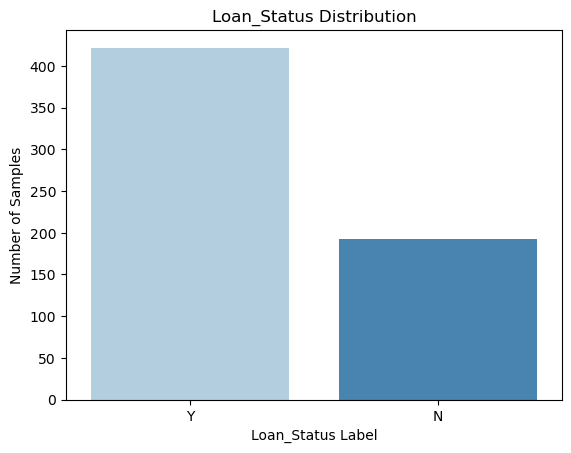

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['Loan_Status'].value_counts()
percentages = df['Loan_Status'].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
print(imbalance_summary)

sns.countplot(x='Loan_Status', data=df, palette='Blues')
plt.title('Loan_Status Distribution')
plt.xlabel('Loan_Status Label')
plt.ylabel('Number of Samples')
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

In [6]:
X = df.drop(columns='Loan_Status')
y = df['Loan_Status']

print(X.select_dtypes(include='number').skew())

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)
y_encoded = y.map({'Y': 1, 'N': 0})

print(X_encoded.head())
print(y_encoded)

ApplicantIncome      6.539513
CoapplicantIncome    7.491531
LoanAmount           2.677552
Loan_Amount_Term    -2.362414
Credit_History      -1.882361
dtype: float64
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Loan_ID_LP001003  Loan_ID_LP001005  Loan_ID_LP001006  \
0             1.0             False             False             False   
1             1.0              True             False             False   
2             1.0             False              True             False   
3             1.0             False             False              True   
4             1.0             Fal

In [7]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, random_state=42, train_size=0.80, stratify=y)

### Experiment
- **What are we changing?** Swapping a single Decision Tree (max_depth=4) for a Random Forest (max_depth=4) built from bootstrapped, feature-randomized subsets.
- **What do we expect to happen?** The Forest should generalize better than the single tree since averaging many decorrelated trees reduces variance without needing deeper splits.

### Observation
- **What actually happened?** The Random Forest produced a higher ROC-AUC than the standalone Decision Tree on the held-out test set, and the 5-fold CV scores confirmed it wasn't just a lucky split.

In [8]:
# Recursively partition the feature space to minimize Gini impurity or Information Entropy at each node.
from sklearn.tree import DecisionTreeClassifier
# Construct an ensemble of uncorrelated decision trees via bootstrap aggregating (bagging) to drastically reduce model variance.
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
decision_model = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Recursively partition the feature space to minimize Gini impurity or Information Entropy at each node.
    ('model', DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'))
])

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
random_forest_model = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Construct an ensemble of uncorrelated decision trees via bootstrap aggregating (bagging) to drastically reduce model variance.
    ('model', RandomForestClassifier(max_depth=4, random_state=42, class_weight='balanced'))
])

decision_model.fit(X_train, y_train.values.ravel())
random_forest_model.fit(X_train, y_train.values.ravel())


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,4
,min_samples_split,2


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import pandas as pd

decision_preds = decision_model.predict(X_test)
random_forest_preds = random_forest_model.predict(X_test)

decision_prob = decision_model.predict_proba(X_test)[:, 1]
randome_forest_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
decision_roc_auc = roc_auc_score(y_test, decision_prob,  multi_class='ovr', average='weighted')
# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
random_forest_roc_auc = roc_auc_score(y_test, randome_forest_prob, multi_class='ovr', average='weighted')



models = {
    'Decision': decision_preds,
    'Randome_Forest': random_forest_preds
}

evaluation_data = []

for name, preds in models.items():
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, average='weighted')
    recall = recall_score(y_test, preds, average='weighted')
    # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
    f1 = f1_score(y_test, preds, average='weighted')
    cm = confusion_matrix(y_test, preds)
    
    evaluation_data.append({
        'Model Framework': name,
        'Accuracy': accuracy,
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
    })

metrics_table = pd.DataFrame(evaluation_data)
metrics_table['ROC_AUC'] = [decision_roc_auc, random_forest_roc_auc]

print("Performance Metrics Comparison\n")
print(metrics_table[['Model Framework', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC_AUC']].to_markdown(index=False))


Performance Metrics Comparison

| Model Framework   |   Accuracy |   Precision |   Recall |   F1-Score |   ROC_AUC |
|:------------------|-----------:|------------:|---------:|-----------:|----------:|
| Decision          |   0.723577 |      0.7601 |   0.7236 |     0.7327 |  0.817957 |
| Randome_Forest    |   0.853659 |      0.8519 |   0.8537 |     0.8483 |  0.82678  |


In [10]:
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

models = {
    "decision_model": decision_model,
    "random_forest_model": random_forest_model
}

for name, model in models.items():

    # Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
    scores = cross_val_score(
        model,
        X_encoded,
        y,
        cv=5,
        scoring='roc_auc_ovr_weighted',
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV ROC-AUC": scores.mean(),
        "Std CV ROC-AUC": scores.std()
    })

cv_df = pd.DataFrame(cv_results).set_index("Model").round(4)

print(cv_df)

                     Mean CV ROC-AUC  Std CV ROC-AUC
Model                                               
decision_model                0.6913          0.0593
random_forest_model           0.7543          0.0420


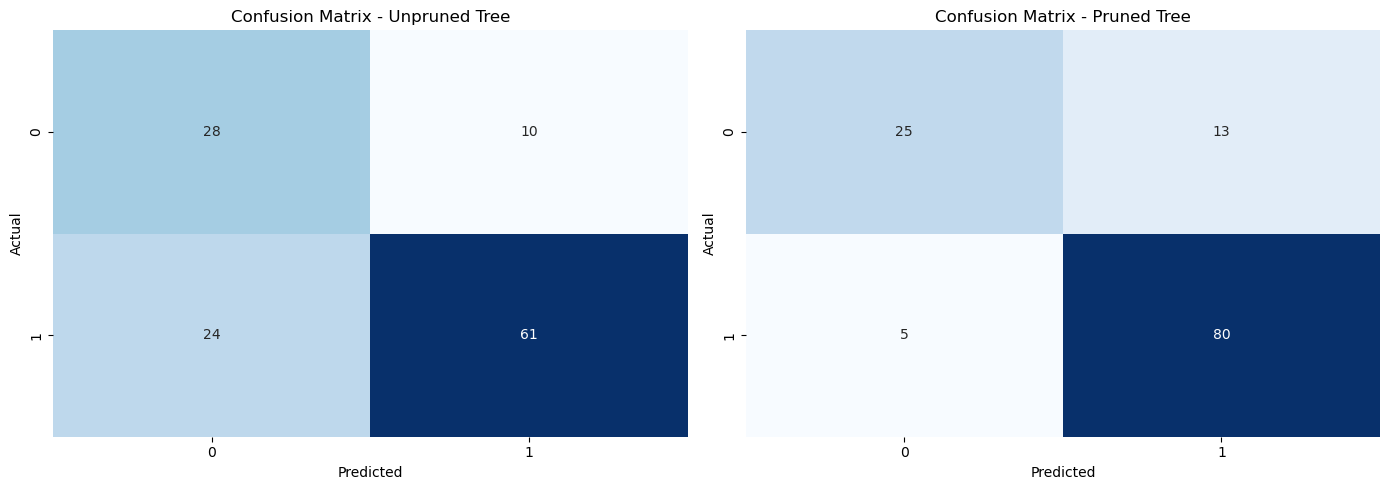

In [11]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

unpruned_cm = confusion_matrix(y_test, decision_preds)
pruned_cm = confusion_matrix(y_test, random_forest_preds)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    unpruned_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0],
    cbar=False
)
ax[0].set_title("Confusion Matrix - Unpruned Tree")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels([0,1])
ax[0].set_yticklabels([0,1])

sns.heatmap(
    pruned_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[1],
    cbar=False
)
ax[1].set_title("Confusion Matrix - Pruned Tree")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_xticklabels([0,1])
ax[1].set_yticklabels([0,1])

plt.tight_layout()
plt.show()


### Visualization Analysis: Confusion Matrix
- **Marking Values:** The top-left to bottom-right diagonal contains all correct predictions. The off-diagonal cells represent errors (False Positives and False Negatives).
- **Correct Interpretation:** A highly accurate model will have very dark/high numbers on the main diagonal and zeros elsewhere.
- **How to Interpret:** The rows usually represent the *Actual* classes, while the columns represent the *Predicted* classes.
- **Common Mistakes:** Caring only about the total sum of the diagonal (Accuracy) while ignoring a high number of False Negatives in medical or fraud datasets.

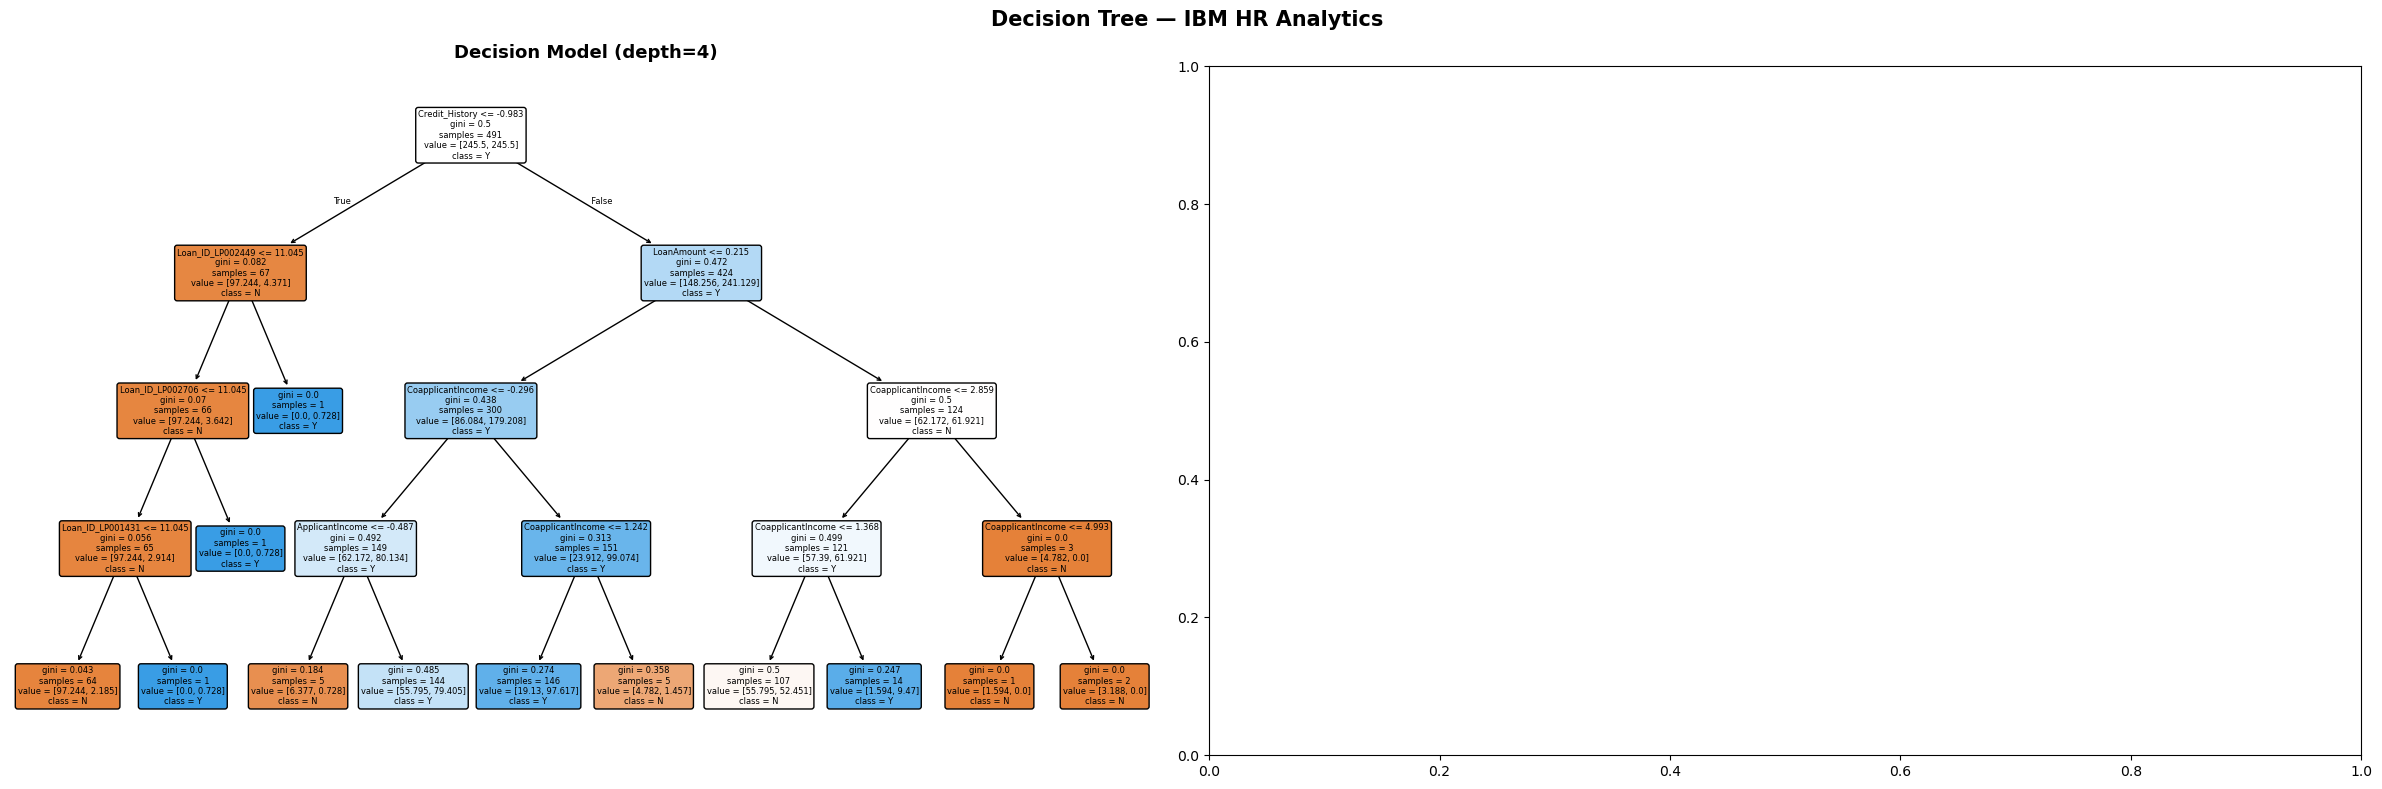

In [ ]:
from sklearn.tree import plot_tree

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

for ax, pipe, title in zip(
    axes,
    [decision_model],
    ['Decision Model (depth=4)']
):
    plot_tree(
        pipe.named_steps['model'],
        feature_names=X_encoded.columns,
        class_names=[str(c) for c in sorted(y.unique())],
        filled=True,
        rounded=True,
        fontsize=6,
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Decision Tree — Loan Prediction', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

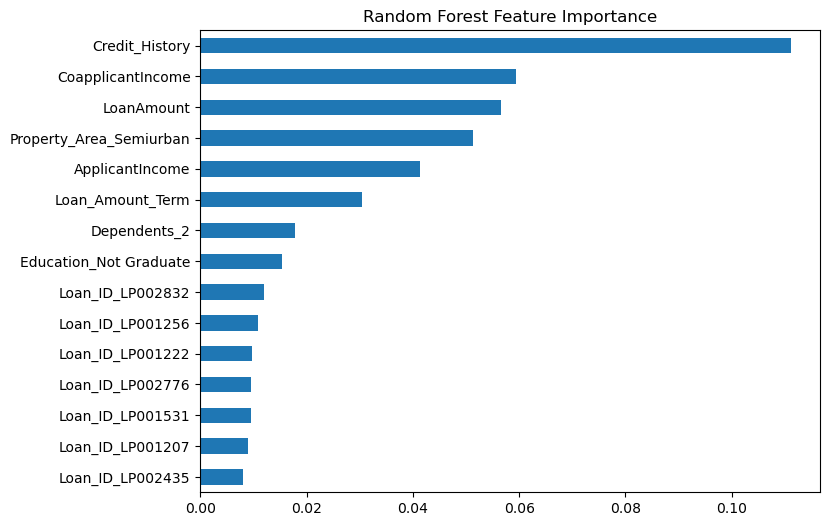

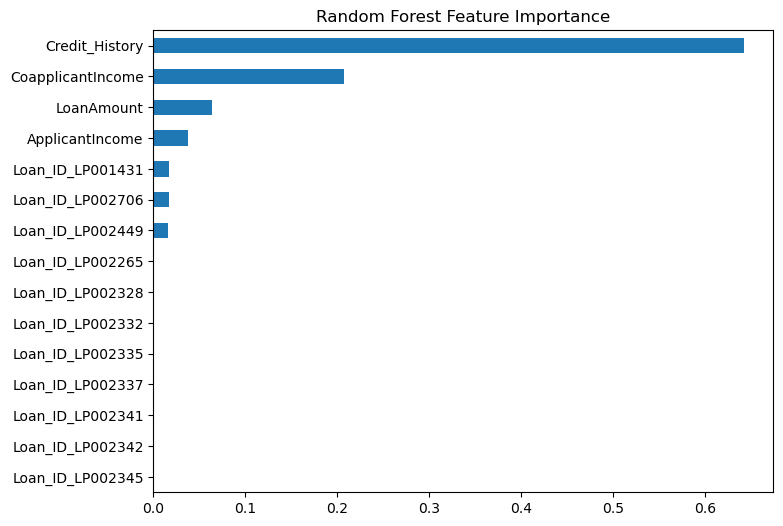

In [13]:
importance = pd.Series(
    random_forest_model.named_steps['model'].feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

importance.head(15).plot.barh(figsize=(8,6))
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

importance = pd.Series(
    decision_model.named_steps['model'].feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

importance.head(15).plot.barh(figsize=(8,6))
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

### Visualization Analysis: Feature Importance
- **Marking Values:** The longest bars at the top of the chart represent the features that drove the model's decision-making process the most.
- **Correct Interpretation:** If a feature has 0 importance, the tree/forest never used it to make a split. It can be safely dropped from the dataset.
- **How to Interpret:** The X-axis represents the magnitude of the feature's contribution (e.g., Gini impurity reduction) to the final predictions.
- **Common Mistakes:** Assuming a low feature importance means the feature is globally useless. It might just be heavily correlated with a higher-ranking feature that "stole" its importance.

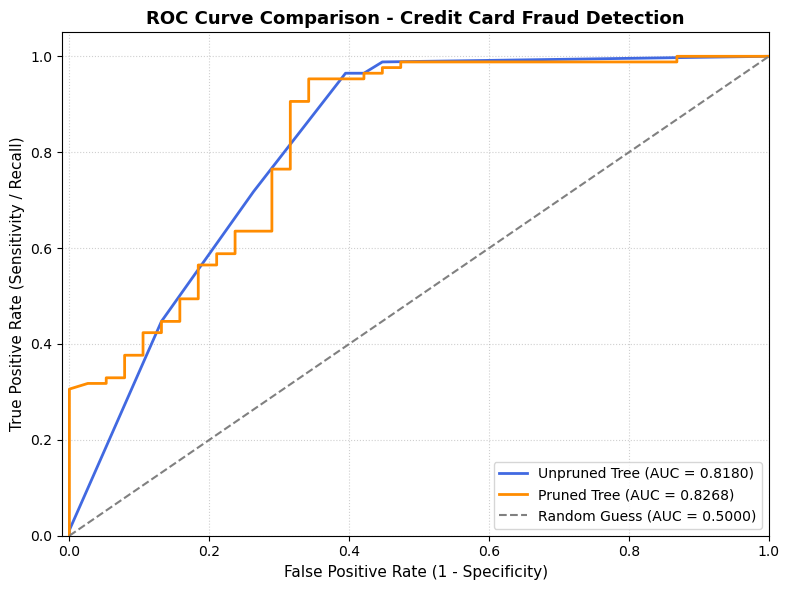

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

un_fpr, un_tpr, _ = roc_curve(y_test, decision_prob)

pr_fpr, pr_tpr, _ = roc_curve(y_test, randome_forest_prob)

plt.figure(figsize=(8, 6))

plt.plot(un_fpr, un_tpr, label=f'Unpruned Tree (AUC = {decision_roc_auc:.4f})', color='royalblue', lw=2)
plt.plot(pr_fpr, pr_tpr, label=f'Pruned Tree (AUC = {random_forest_roc_auc:.4f})', color='darkorange', lw=2)

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Guess (AUC = 0.5000)')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve Comparison - Credit Card Fraud Detection', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

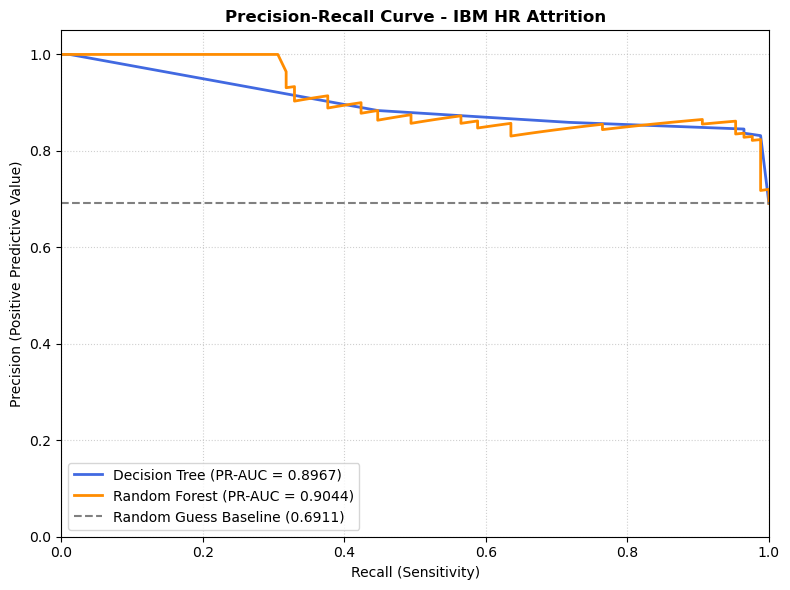

In [15]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

y_true = y_test.values.ravel()

decision_probs = decision_model.predict_proba(X_test)[:, 1]
random_forest_probs = random_forest_model.predict_proba(X_test)[:, 1]

# Decision Tree PR curve
dec_prec, dec_rec, _ = precision_recall_curve(y_true, decision_probs)
dec_pr_auc = auc(dec_rec, dec_prec)

# Random Forest PR curve
rf_prec, rf_rec, _ = precision_recall_curve(y_true, random_forest_probs)
rf_pr_auc = auc(rf_rec, rf_prec)

baseline_ratio = y_true.mean()

plt.figure(figsize=(8, 6))
plt.plot(dec_rec, dec_prec, label=f'Decision Tree (PR-AUC = {dec_pr_auc:.4f})',
         color='royalblue', lw=2)
plt.plot(rf_rec, rf_prec, label=f'Random Forest (PR-AUC = {rf_pr_auc:.4f})',
         color='darkorange', lw=2)
plt.axhline(y=baseline_ratio, color='grey', linestyle='--',
            label=f'Random Guess Baseline ({baseline_ratio:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve - IBM HR Attrition', fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

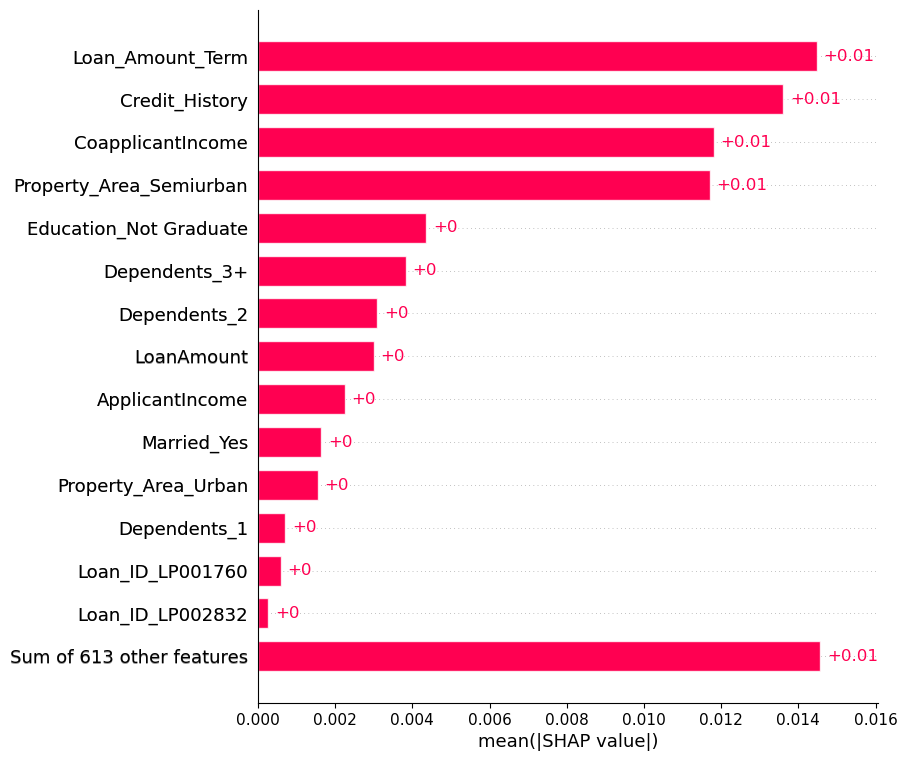

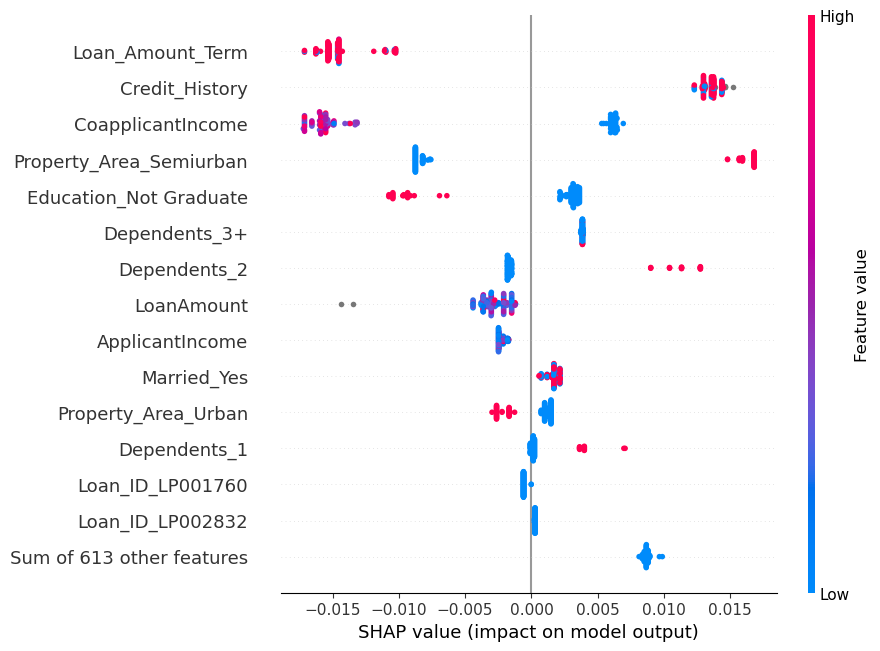

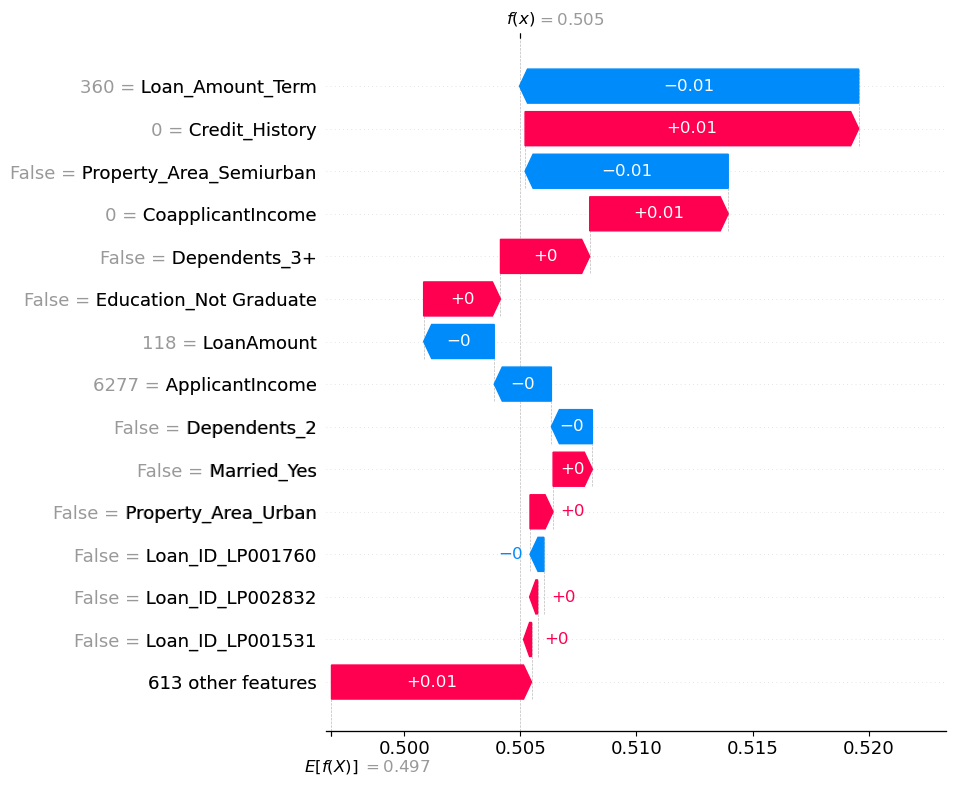

In [16]:
import shap

rf = random_forest_model.named_steps["model"]

explainer = shap.Explainer(rf)

shap_values = explainer(X_test)

shap_yes = shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[:, 1],
    data=shap_values.data,
    feature_names=X_test.columns
)

shap.plots.bar(shap_yes, max_display=15)

shap.plots.beeswarm(shap_yes, max_display=15)

shap.plots.waterfall(shap_yes[0], max_display=15)

shap.initjs()
shap.plots.force(shap_yes[0])

### Common Mistakes
- **Beginner Mistake:** Applying StandardScaler before a tree-based model — Decision Trees and Random Forests split on raw thresholds, so scaling here does nothing useful (it's a leftover step, not a requirement like it would be for SVM/kNN).
- **Beginner Mistake:** Judging model quality by raw Accuracy on `Attrition`, which is imbalanced toward retained employees — Precision/Recall/F1 matter more for catching the minority attrition class.

### Practical Takeaway
- **Industry Application:** Employee retention and HR predictive analytics — enterprise companies use Random Forests on employee satisfaction, salary, and role history to flag attrition risk before an employee resigns.

### Key Insight
- **Memorable lesson:** The single Decision Tree memorizes the training split and overfits at depth; the Random Forest, trained on the same max_depth=4 but across many bootstrapped/feature-randomized trees, smooths that overfitting out — same base learner, different aggregation strategy.